# [Title]

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

**To what extent do socio-demographic characteristics predict the spatial distribution of primary care deserts across New York City's community districts?**

## 3. Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Data Sources


*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable | Type | Description | Notes |
|---|---|---|---|
| `desert_score` | Numeric | Primary care desert score (0–1). **Dependent variable.** Higher = fewer facilities per capita = worse access. | Derived from NYC Facilities Database |
| `pct_elderly` | Numeric | % of population aged 65 and over | ACS Demographic file — `Pop65pl1P` |
| `median_income` | Numeric | Median household income (USD) | ACS Economic file — `MdHHIncE` |
| `pct_snap` | Numeric | % of households receiving SNAP (food stamps) | ACS Economic file — derived from `Inc_SNAPE` ÷ `Pop_1E` |
| `pct_foreign_born` | Numeric | % of population born outside the USA | ACS Demographic file — `Fb1P` |
| `pop_density` | Numeric | Population per km² | Derived: `Pop_1E` ÷ district area in km² |

In [7]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 34.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import shap

dem            = pd.read_excel('Dem_1923_CDTA.xlsx')
econ           = pd.read_excel('Econ_1923_CDTA.xlsx')
districts      = gpd.read_file('community_districts.geojson')
facilities_raw = pd.read_csv('nyc_facilities.csv', low_memory=False)

print('Dem:',       dem.shape)
print('Econ:',      econ.shape)
print('Districts:', districts.shape)
print('Facilities:', facilities_raw.shape)
print('\nDistrict columns:', districts.columns.tolist())
print('CRS:', districts.crs)
print('\nSample GeoIDs (ACS):', dem['GeoID'].head().tolist())
print('Sample BoroCD (GeoJSON):', districts['BoroCD'].head().tolist())
print('\nFacilities columns:', facilities_raw.columns.tolist())

Dem: (71, 535)
Econ: (71, 660)
Districts: (71, 3)
Facilities: (34708, 38)

District columns: ['OBJECTID', 'BoroCD', 'geometry']
CRS: EPSG:4326

Sample GeoIDs (ACS): ['BK01', 'BK02', 'BK03', 'BK04', 'BK05']
Sample BoroCD (GeoJSON): [410, 480, 483, 226, 313]

Facilities columns: ['uid', 'facname', 'addressnum', 'streetname', 'address', 'city', 'boro', 'borocode', 'zipcode', 'latitude', 'longitude', 'xcoord', 'ycoord', 'bin', 'bbl', 'cd', 'council', 'ct2010', 'ct2020', 'nta2010', 'nta2020', 'facgroup', 'facsubgrp', 'factype', 'capacity', 'captype', 'optype', 'opname', 'opabbrev', 'overlevel', 'overagency', 'overabbrev', 'datasource', 'facdomain', 'schooldist', 'policeprct', 'servarea', 'geometry']


### 3.2 Preprocessing 

In [23]:
print('Dem:', dem.shape)
print('Econ:', econ.shape)
print('Districts:', districts.shape)
print(districts.columns.tolist())

Dem: (71, 535)
Econ: (71, 660)
Districts: (71, 3)
['OBJECTID', 'BoroCD', 'geometry']


Filter primary care facilities:

In [24]:
domain_cols = [c for c in facilities_raw.columns
               if any(k in c.lower() for k in ['domain','group','type','sub'])]
print('Category columns found:', domain_cols)

for col in domain_cols[:2]:
    if col in facilities_raw.columns:
        print(f'\nTop values in [{col}]:')
        print(facilities_raw[col].value_counts().head(15))

Category columns found: ['facgroup', 'facsubgrp', 'factype', 'captype', 'optype', 'facdomain']

Top values in [facgroup]:
facgroup
YOUTH SERVICES                                   5267
DAY CARE AND PRE-KINDERGARTEN                    4296
TRANSPORTATION                                   3464
HEALTH CARE                                      3360
SCHOOLS (K-12)                                   3104
PARKS AND PLAZAS                                 2573
HUMAN SERVICES                                   2503
CULTURAL INSTITUTIONS                            2393
CHILD SERVICES AND WELFARE                       2068
SOLID WASTE                                      1695
HISTORICAL SITES                                 1083
OFFICES, TRAINING, AND TESTING                    528
VOCATIONAL AND PROPRIETARY SCHOOLS                465
CITY AGENCY PARKING, MAINTENANCE, AND STORAGE     413
CAMPS                                             324
Name: count, dtype: int64

Top values in [facsubgrp]:
facsu

Spatial join facilities → community districts:

In [25]:
PRIMARY_CARE_KEYWORDS = [
    'hospital', 'clinic', 'health center', 'health centre',
    'outpatient', 'federally qualified', 'fqhc',
    'primary care', 'community health', 'diagnostic'
]

def is_primary_care(row):
    for col in ['factype', 'facsubgrp', 'facgroup', 'facdomain']:
        if col in row.index and isinstance(row[col], str):
            if any(kw in row[col].lower() for kw in PRIMARY_CARE_KEYWORDS):
                return True
    return False

mask = facilities_raw.apply(is_primary_care, axis=1)
facilities_pc = facilities_raw[mask].copy()
print(f'Total facilities: {len(facilities_raw):,}')
print(f'Primary care filtered: {len(facilities_pc):,}')

# identify lat/lon columns
lat_col = next((c for c in facilities_pc.columns if c.lower() in ['latitude','lat','y']), None)
lon_col = next((c for c in facilities_pc.columns if c.lower() in ['longitude','lon','long','x']), None)
print(f'\nLat column: {lat_col} | Lon column: {lon_col}')

# drop missing / out-of-bounds coordinates
facilities_pc = facilities_pc.dropna(subset=[lat_col, lon_col])
facilities_pc = facilities_pc[
    facilities_pc[lon_col].between(-74.3, -73.7) &
    facilities_pc[lat_col].between(40.4, 40.95)
]

# convert to GeoDataFrame and spatial join
gdf_facilities = gpd.GeoDataFrame(
    facilities_pc,
    geometry=gpd.points_from_xy(facilities_pc[lon_col], facilities_pc[lat_col]),
    crs='EPSG:4326'
)
districts = districts.to_crs('EPSG:4326')

joined = gpd.sjoin(gdf_facilities, districts[['BoroCD','geometry']],
                   how='left', predicate='within')

facility_counts = joined.groupby('BoroCD').size().reset_index(name='facility_count')
print(f'\nDistricts with ≥1 facility: {len(facility_counts)}')
print(facility_counts.describe())

Total facilities: 34,708
Primary care filtered: 1,918

Lat column: latitude | Lon column: longitude

Districts with ≥1 facility: 59
           BoroCD  facility_count
count   59.000000       59.000000
mean   280.305085       31.694915
std    118.769010       15.845433
min    101.000000        8.000000
25%    203.500000       21.000000
50%    306.000000       28.000000
75%    402.500000       39.500000
max    503.000000       84.000000


In [26]:
# demographic features
dem_features = dem[['GeoID', 'GeogName', 'Borough',
                     'Pop_1E',    # total population
                     'Pop65pl1P', # % aged 65+
                     ]].copy()
dem_features.columns = ['GeoID', 'GeogName', 'Borough',
                         'total_pop', 'pct_elderly']

# economic features
econ_features = econ[['GeoID', 'MdHHIncE', 'Inc_SNAPE']].copy()
econ_features.columns = ['GeoID', 'median_income', 'snap_count']

# merge dem + econ
acs = dem_features.merge(econ_features, on='GeoID')
acs['pct_snap'] = (acs['snap_count'] / acs['total_pop'] * 100).round(2)

# GeoID → BoroCD crosswalk  (e.g. BK01 → 301, MN03 → 103)
prefix_map = {'MN': 100, 'BX': 200, 'BK': 300, 'QN': 400, 'SI': 500}

def geoid_to_borocd(geoid):
    prefix = geoid[:2]
    num    = int(geoid[2:])
    return prefix_map.get(prefix, np.nan) + num if prefix in prefix_map else np.nan

acs['BoroCD'] = acs['GeoID'].apply(geoid_to_borocd)
acs = acs.dropna(subset=['BoroCD'])
acs['BoroCD'] = acs['BoroCD'].astype(int)

print(f'ACS rows after crosswalk: {len(acs)}')
print(acs[['GeoID', 'BoroCD', 'total_pop', 'pct_elderly', 'median_income']].head(8).to_string())

ACS rows after crosswalk: 71
  GeoID  BoroCD  total_pop  pct_elderly  median_income
0  BK01     301     203002          9.2       102807.0
1  BK02     302     125637         12.5       145094.0
2  BK03     303     180283         10.3        77546.0
3  BK04     304     111975         10.4        83441.0
4  BK05     305     201036         14.6        54145.0
5  BK06     306     121009         12.2       165947.0
6  BK07     307     120253         12.7        84767.0
7  BK08     308     109719         12.6        90978.0


Extract ACS features & build GeoID → BoroCD crosswalk:

In [28]:
# demographic features
dem_features = dem[['GeoID', 'GeogName', 'Borough',
                     'Pop_1E',    # total population
                     'Pop65pl1P', # % aged 65+
                     ]].copy()
dem_features.columns = ['GeoID', 'GeogName', 'Borough',
                         'total_pop', 'pct_elderly']

# economic features
econ_features = econ[['GeoID', 'MdHHIncE', 'Inc_SNAPE']].copy()
econ_features.columns = ['GeoID', 'median_income', 'snap_count']

# merge dem + econ
acs = dem_features.merge(econ_features, on='GeoID')
acs['pct_snap'] = (acs['snap_count'] / acs['total_pop'] * 100).round(2)

# GeoID → BoroCD crosswalk  (e.g. BK01 → 301, MN03 → 103)
prefix_map = {'MN': 100, 'BX': 200, 'BK': 300, 'QN': 400, 'SI': 500}

def geoid_to_borocd(geoid):
    prefix = geoid[:2]
    num    = int(geoid[2:])
    return prefix_map.get(prefix, np.nan) + num if prefix in prefix_map else np.nan

acs['BoroCD'] = acs['GeoID'].apply(geoid_to_borocd)
acs = acs.dropna(subset=['BoroCD'])
acs['BoroCD'] = acs['BoroCD'].astype(int)

print(f'ACS rows after crosswalk: {len(acs)}')
print(acs[['GeoID', 'BoroCD', 'total_pop', 'pct_elderly', 'median_income']].head(8).to_string())


ACS rows after crosswalk: 71
  GeoID  BoroCD  total_pop  pct_elderly  median_income
0  BK01     301     203002          9.2       102807.0
1  BK02     302     125637         12.5       145094.0
2  BK03     303     180283         10.3        77546.0
3  BK04     304     111975         10.4        83441.0
4  BK05     305     201036         14.6        54145.0
5  BK06     306     121009         12.2       165947.0
6  BK07     307     120253         12.7        84767.0
7  BK08     308     109719         12.6        90978.0


Merge ACS + facility counts onto district polygons:

In [29]:
df = acs.merge(facility_counts, on='BoroCD', how='left')
df['facility_count'] = df['facility_count'].fillna(0)

gdf = districts.merge(df, on='BoroCD', how='inner')

# population density (requires projected CRS for accurate area in km²)
gdf_proj           = gdf.to_crs('EPSG:32618')    # UTM zone 18N – New York
gdf['area_km2']    = gdf_proj.geometry.area / 1e6
gdf['pop_density'] = gdf['total_pop'] / gdf['area_km2']

# facilities per 10,000 residents
gdf['facilities_per_10k'] = (
    gdf['facility_count'] / (gdf['total_pop'] / 10_000)
).round(4)

# ── Desert Score (target variable) ─────────────────────────────────────────
# normalise facilities_per_10k to [0,1], then invert:
# desert_score = 1 → fewest facilities (worst access)
# desert_score = 0 → most facilities  (best access)
f = gdf['facilities_per_10k']
gdf['desert_score'] = 1 - (f - f.min()) / (f.max() - f.min())

print(f'Final modelling dataset: {gdf.shape}')
print(gdf[['GeogName', 'facilities_per_10k', 'desert_score',
           'pct_elderly', 'median_income', 'pct_snap',
           'pop_density']].head(10).to_string())

Final modelling dataset: (71, 16)
                                                   GeogName  facilities_per_10k  desert_score  pct_elderly  median_income  pct_snap   pop_density
0  QN10 South Ozone Park-Howard Beach (CD 10 Approximation)              0.7386      0.909224         18.5        94552.0      4.78   8474.335125
1             QN80 LaGuardia Airport (JIA 80 Approximation)                 NaN           NaN          NaN            NaN       NaN      0.000000
2     QN83 JFK International Airport (JIA 83 Approximation)                 NaN           NaN          NaN            NaN       NaN      0.000000
3               BX26 Van Cortlandt Park (JIA 26 Equivalent)              0.0000      1.000000          NaN       106249.0      0.00     11.927652
4    BK13 Coney Island-Brighton Beach (CD 13 Approximation)              2.0882      0.743354         26.4        45489.0     15.84  13440.588235
5   MN05 Midtown-Flatiron-Union Square (CD 5 Approximation)              8.1365      0.000

Mapping:

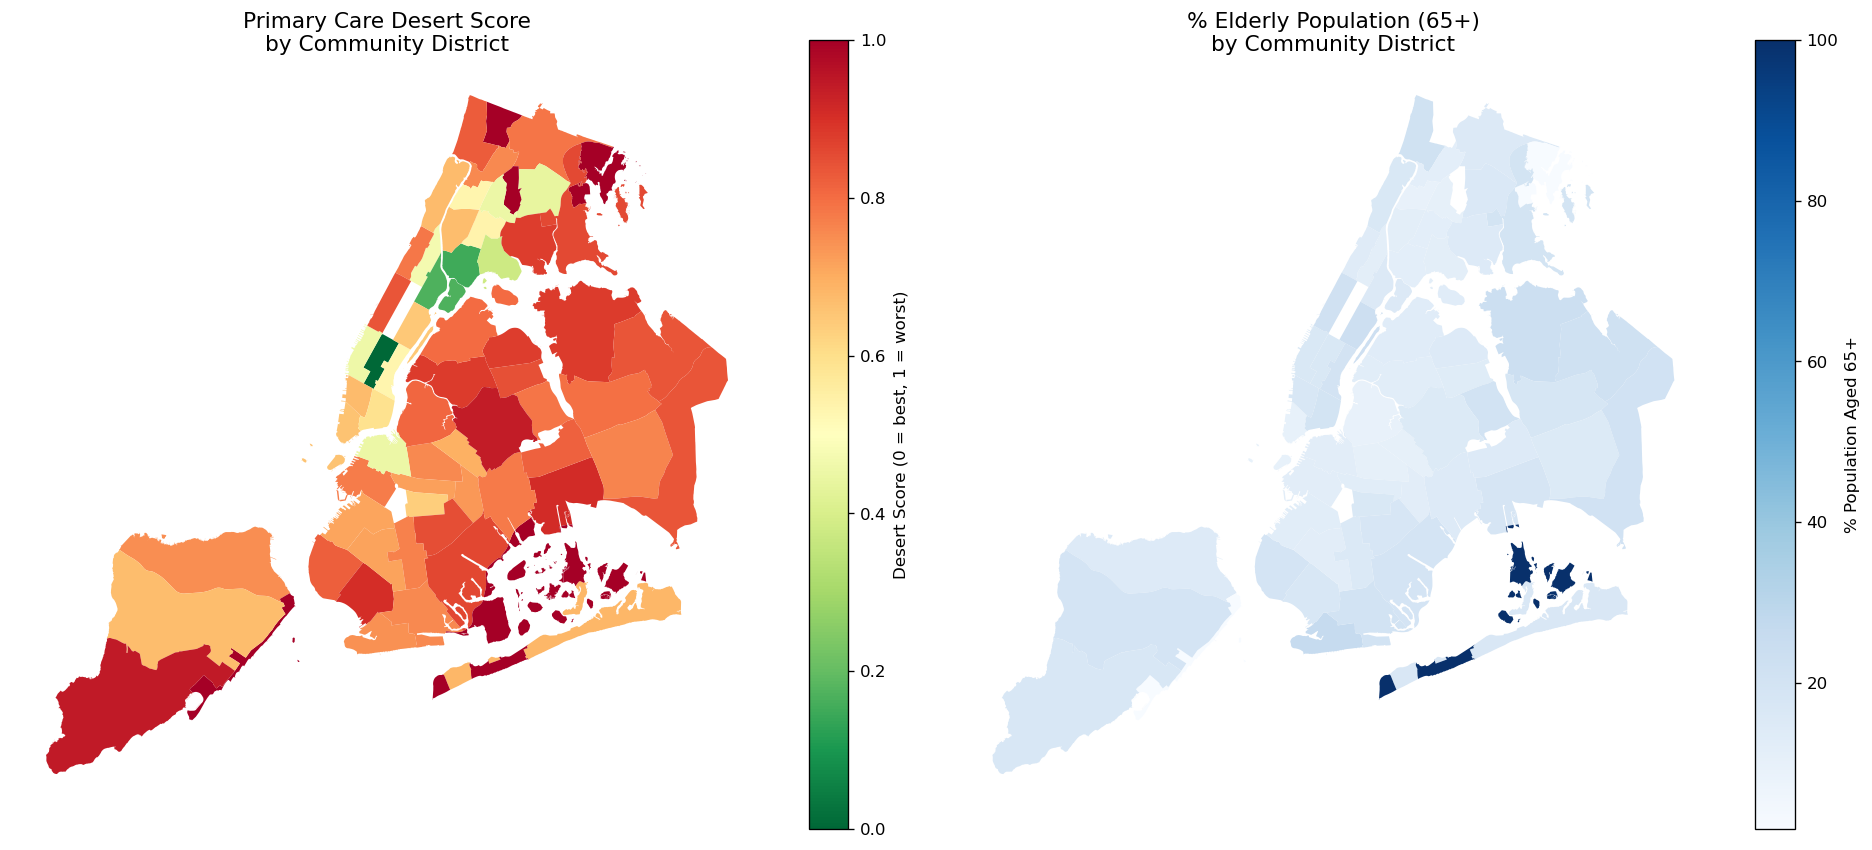

In [30]:
# ── EDA: Choropleth maps ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

gdf.plot(column='desert_score', ax=axes[0], legend=True, cmap='RdYlGn_r',
         legend_kwds={'label': 'Desert Score (0 = best, 1 = worst)'})
axes[0].set_title('Primary Care Desert Score\nby Community District', fontsize=13)
axes[0].axis('off')

gdf.plot(column='pct_elderly', ax=axes[1], legend=True, cmap='Blues',
         legend_kwds={'label': '% Population Aged 65+'})
axes[1].set_title('% Elderly Population (65+)\nby Community District', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

EDA Correlation matrix:

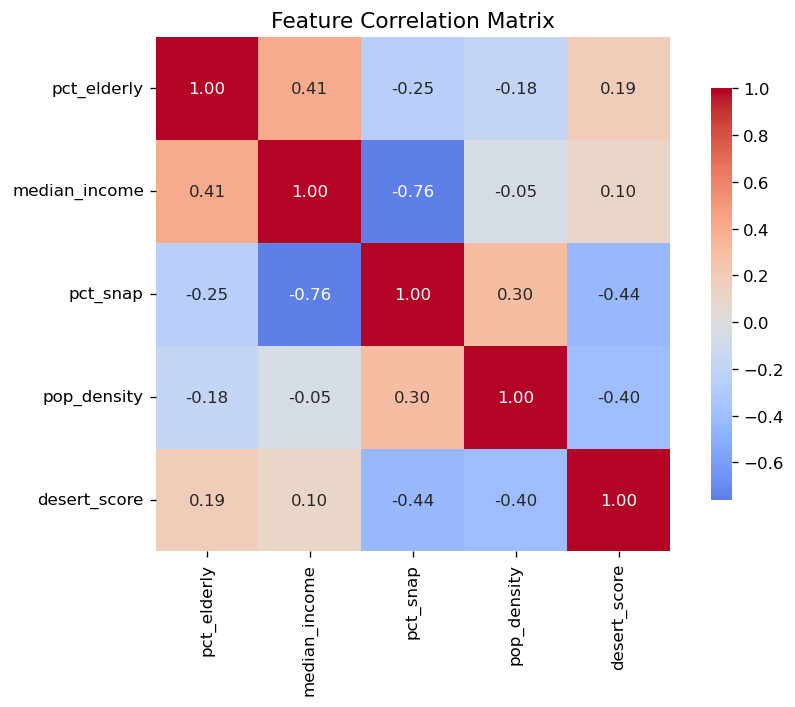

In [32]:
feature_cols = ['pct_elderly', 'median_income', 'pct_snap',
                'pop_density', 'desert_score']

corr = gdf[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

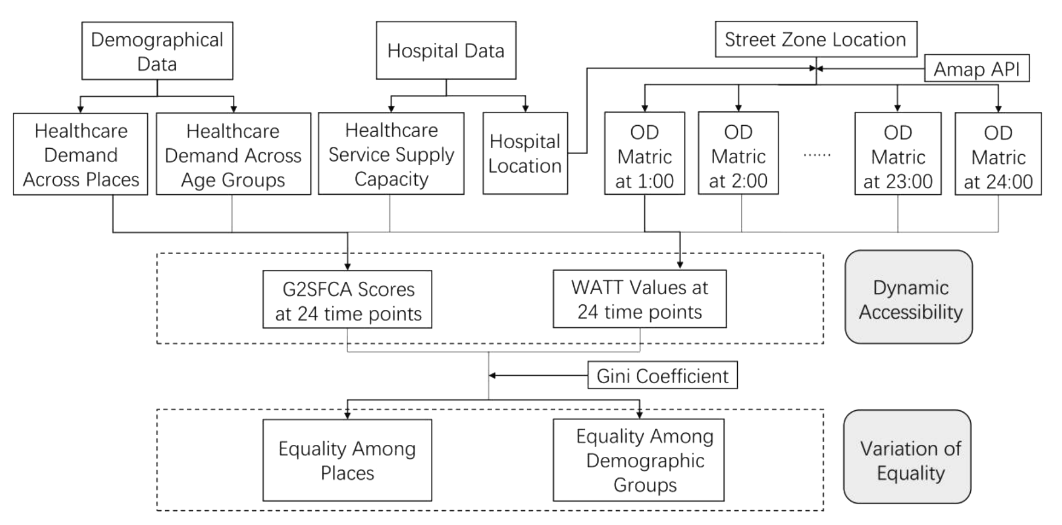

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)